In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping



print('Setup is ready!')

Setup is ready!


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date

In [30]:
df = pd.read_csv('/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/W4_project_NLP/data.csv')
df.head()

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [31]:
print('Shape:', df.shape)
print('Kolommen:', df.columns.tolist())
print('Datatypes:')
print(df.dtypes)
print('Lege waarden:')
print(df.isnull().sum())


Shape: (39942, 5)
Kolommen: ['label', 'title', 'text', 'subject', 'date']
Datatypes:
label      int64
title        str
text         str
subject      str
date         str
dtype: object
Lege waarden:
label      0
title      0
text       0
subject    0
date       0
dtype: int64


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns="label"),
    df['label'],
    test_size=0.2,
    random_state=42
)

print('Train:', X_train.shape)
print('Test: ', X_test.shape)

Train: (31953, 4)
Test:  (7989, 4)


In [33]:
stop_words = set(stopwords.words('english'))  # dutch, french, german...


# 👇 NIEUW toevoegen
stop_words.update([
    "reuters", "said", "washington",
    "monday", "tuesday", "wednesday",
    "thursday", "friday"
])
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()

def preprocess(text):
    # 1. HTML cleaning - weglaten als: geen HTML
    text = re.sub(r'<(script|style).*?>.*?</\1>', '', text, flags=re.DOTALL)
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    text = re.sub(r'<.*?>', '', text)

    # 2. Prefixed b - weglaten als: geen bytes strings
    text = re.sub(r'^b\s+', '', text)

    # 3. Lowercase - MOET voor stopwords! - weglaten als: hoofdletters betekenis
    text = text.lower()

    # 4. Special characters - weglaten als: symbolen belangrijk
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 5. Numbers - weglaten als: cijfers betekenis hebben
    text = re.sub(r'\d+', ' ', text)

    # 6. Losse letters
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)
    text = re.sub(r'^\s*[a-zA-Z]\s+', ' ', text)

    # 7. Dubbele spaties
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Tokenization - MOET voor stopwords en lemmatization!
    # Splitst tekst in lijst van individuele woorden
    tokens = word_tokenize(text)

    # 9. Punctuation removal op token niveau
    tokens = [w for w in tokens if w not in string.punctuation]

    # 10. Stopwords - MOET na lowercase EN na tokenization!
    # weglaten als: grammatica of woordvolgorde belangrijk
    tokens = [w for w in tokens if w not in stop_words]

    # 11. Lemmatization - werkt op individuele tokens!
    # MOET na tokenization, MOET voor feature extraction!
    # alternatief: stemmer.stem(w) sneller maar ruwer
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # 12. Terug samenvoegen naar string
    # Waarom: BOW en TF-IDF verwachten strings als input
    return ' '.join(tokens)

# Toepassen - apart op train en test
X_train["combined"] = (X_train["title"] + " " + X_train["text"]).apply(preprocess)
X_test["combined"]  = (X_test["title"] + " " + X_test["text"]).apply(preprocess)

print('Na preprocessing:')
print(X_train.iloc[0])

Na preprocessing:
title       MN: Mayoral Candidate Wants To DISARM COPS Aft...
text         Minneapolis mayoral candidate Raymond Dehn pr...
subject                                             left-news
date                                             Jul 30, 2017
combined    mn mayoral candidate want disarm cop muslim co...
Name: 38232, dtype: str


In [34]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train["combined"])
X_test_tfidf  = tfidf.transform(X_test["combined"])

print('TF-IDF shape:', X_train_tfidf.shape)

TF-IDF shape: (31953, 20000)


In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
y_pred = model.predict(X_test_tfidf)

In [37]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9817248716985856
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3996
           1       0.98      0.99      0.98      3993

    accuracy                           0.98      7989
   macro avg       0.98      0.98      0.98      7989
weighted avg       0.98      0.98      0.98      7989



In [39]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("NB Accuracy:", accuracy_score(y_test, y_pred_nb))

NB Accuracy: 0.9422956565277256


In [40]:
from sklearn.metrics import accuracy_score

# Train accuracy
y_train_pred = model.predict(X_train_tfidf)
train_acc = accuracy_score(y_train, y_train_pred)

# Test accuracy
y_test_pred = model.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.9873564297562044
Test accuracy: 0.9817248716985856


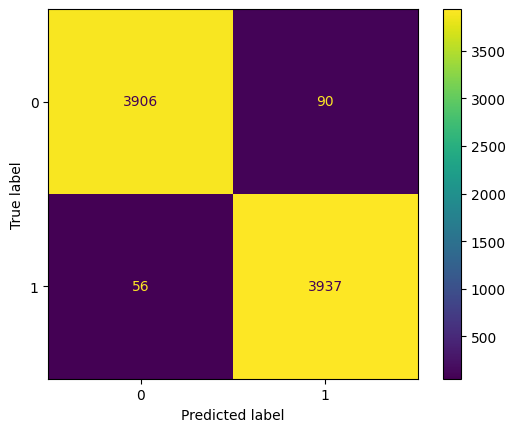

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

In [42]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]

top_fake = np.argsort(coefs)[-10:]
top_real = np.argsort(coefs)[:10]

print("Fake-achtige woorden:")
for i in top_fake:
    print(feature_names[i])

print("\nReal-achtige woorden:")
for i in top_real:
    print(feature_names[i])

Fake-achtige woorden:
minister
republican
representative
democratic
nov
president barack
spokesman
presidential
statement
president donald

Real-achtige woorden:
video
via
image
president trump
read
gop
hillary
featured image
featured
watch


In [43]:
errors = (y_test != y_pred)

for i in X_test[errors].index[:5]:
    print("TEXT:", X_test["combined"].loc[i])
    print("ECHT:", y_test.loc[i])
    print("VOORSPELLING:", y_pred[list(X_test.index).index(i)])
    print()

TEXT: nsa architect nsa snooping expires fed continue surveillance american phone record nsa whistleblower interesting thing say happen right snoop expired ap say happening nsa eight day blocking senate republican agreed begin debate house bill would overhaul national security agency handling american calling record preserving domestic surveillance provision remarkable turnabout happen soon enough prevent law governing program expiring midnight sunday republican sen rand paul presidential contender stood way extending program angering gop colleague frustrating intelligence law enforcement official question whether senate pas bill house live surveillance program resume significant change phone record handled remain dormant senate vote measure known usa freedom act come earlier senate republican aide expected amendment major revision bill gone past brink senate must embrace necessity acting responsibly adam schiff ranking democrat house intelligence committee statement sunday senate vote

In [44]:
print(df[df["label"] == 1][["title"]].head(3))
print(df[df["label"] == 0][["title"]].head(3))

                                               title
0  As U.S. budget fight looms, Republicans flip t...
1  U.S. military to accept transgender recruits o...
2  Senior U.S. Republican senator: 'Let Mr. Muell...
                                                   title
19999   Donald Trump Sends Out Embarrassing New Year’...
20000   Drunk Bragging Trump Staffer Started Russian ...
20001   Sheriff David Clarke Becomes An Internet Joke...
